# Phase 1 Project 

This project is designed to **analyze a comprehensive flight dataset**  that includes:

        - accident dates, 
        - aircraft types, 
        - registrations, 
        - operators, 
        - fatalities, 
        - locations, 
        - and damages,


By examining patterns in fatal and non-fatal accidents, damage severity, and aircraft types, the project aims to **help investors select aircraft with the optimal balance of safety and financial risk**, enabling data-driven decisions that minimize exposure to catastrophic losses while maximizing long-term return on investment.

Data - from kaggle (https://www.kaggle.com/datasets/anandkushawaha/aviation-crashed-flights-data?resource=download)

### 1. Setup & Configuration

In [234]:
# Import important librabries needed 

# Data Handling 
import pandas as pd
import numpy as np

# Visualization
import matplotlib
import matplotlib.pyplot as plt

# Configure notebook display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8) # Set default figure size for plots


### 2. Data Ingestion

In [235]:
# Path to the dataset obtained from Kaggle

# Path to Excel file
file_path = './flight.csv'

# Load the dataset into a pandas DataFrame
flight_df = pd.read_csv(file_path, index_col=0) # remove index column if not needed

flight_df.head()  # Display the first few rows of the DataFrame

,acc.date,type,reg,operator,fat,location,dmg
0,3 Jan 2022,British Aerospace 4121 Jetstream 41,ZS-NRJ,SA Airlink,0,near Venetia Mine Airport,sub
1,4 Jan 2022,British Aerospace 3101 Jetstream 31,HR-AYY,LANHSA - Línea Aérea Nacional de Honduras S.A,0,Roatán-Juan Manuel Gálvez International Airpor...,sub
2,5 Jan 2022,Boeing 737-4H6,EP-CAP,Caspian Airlines,0,Isfahan-Shahid Beheshti Airport (IFN),sub
3,8 Jan 2022,Tupolev Tu-204-100C,RA-64032,"Cainiao, opb Aviastar-TU",0,Hangzhou Xiaoshan International Airport (HGH),w/o
4,12 Jan 2022,Beechcraft 200 Super King Air,NaN,private,0,"Machakilha, Toledo District, Grahem Creek area",w/o


### 3. Data Profiling / Initial Inspection

In [236]:
# Print the shape of the DataFrame (rows, columns)
print(f"df shape: {df.shape}")

df shape: (0, 9)


#### 3.1 Check for null values and fix it

In [237]:

flight_df.isnull().sum()


acc.date     0
type         0
reg         92
operator    14
fat         12
location     0
dmg          0
dtype: int64

We have a 92 missing values from reg, 14 from opertor and 12 from fat. We have two options:

1. Fill in missing values:
    - Relpace the missing values with appropriate "Unkown"  that enables us to maintain data integrity and allows us to keep all rows without loosing data for better analysis

2. Drop Rows with missing values 
    - Remove all rows with missing data that keeps the analysis clean and focused on known data. The downside is that I lose potentially valuable data and reduce the dataset size

In this project, **option 2** is the best due to reliability. 

3.1.1 Working on missing Values for Reg

In [238]:
# Sample 5 rows where 'reg' column is not null
has_reg = flight_df[flight_df["reg"].notna()].sample(5)
has_reg

,acc.date,type,reg,operator,fat,location,dmg
963,28 Dec 2019,Let L-410UVP-E,9S-GDX,Air Fast Congo,0,Kamina Airport (KMN),sub
1087,6 Jun 2018,Antonov An-2R,YR-DAX,Aeroserv,0,"Baleni, Galati County",w/o
95,22 Jun 2022,Learjet 55C,YV3304,private,6,7 km SSE of Charallave-Óscar Machado Zuloaga A...,w/o
1153,10 Aug 2018,de Havilland Canada DHC-8-402Q Dash 8,N449QX,"Horizon Air, opf Alaska Airlines",1,"Ketron Island, WA",w/o
1032,4 Apr 2018,Cessna 560XL Citation Excel,N900WL,MTC Enterprises LLC,0,"Houston-William P. Hobby Airport, TX (HOU)",w/o


In [239]:
# Sample 5 rows where 'reg' column is null
no_reg = flight_df[flight_df["reg"].isna()].sample(5)
no_reg

,acc.date,type,reg,operator,fat,location,dmg
232,29 Jan 2021,Beechcraft 100 King Air,NaN,private,0,"Crooked Tree, Orange Walk",w/o
365,12 Sep 2021,British Aerospace BAe-125,NaN,private,0,Río Catatumbo,w/o
25,23 Feb 2022,Antonov An-2,NaN,Taraz Zhana Alem,0,10 km S of Aralsk,w/o
1237,8 Dec 2018,Beechcraft 200 Super King Air,NaN,Unknown,0,"Corozo, Sarstún",w/o
1108,26 Jun 2018,Ilyushin Il-76,NaN,Islamic Republic of Iran Air Force - IRIAF,0,Damascus International Airport (DAM),w/o


In [240]:
# Drop rows with missing 'reg' values
flight_df = flight_df.dropna(subset=['reg'])

# Check for remaining missing values
flight_df["reg"].isna().sum()

np.int64(0)

In [241]:
# Assertain that there are no missing values in 'reg' column
assert flight_df["reg"].isna().sum() == 0

3.1.2 Working on missing Values for Operator

In [242]:
# Sample 5 rows where 'operator' column is  not null
has_operator = flight_df[flight_df["operator"].notna()].sample(5)
has_operator

,acc.date,type,reg,operator,fat,location,dmg
247,21 Feb 2021,Beechcraft B300 King Air 350,NAF201,Nigerian Air Force - NAF,7,NE of Abuja-Nnamdi Azikiwe International Airpo...,w/o
592,12 Aug 2020,Beechcraft B200 King Air,N316JP,private,0,"Santa Ana, Bartolomé de Las Casas, Zulia",w/o
1087,6 Jun 2018,Antonov An-2R,YR-DAX,Aeroserv,0,"Baleni, Galati County",w/o
1216,11 Nov 2018,Embraer ERJ-190LR (ERJ-190-100 LR),P4-KCJ,Air Astana,0,NE of Lisbon,sub
451,16 Jan 2020,Beechcraft B200 King Air,N547LM,LifeMed Alaska,0,"NW off Unalaska-Tom Madsen Airport, AK (DUT)",w/o


In [243]:
# Sample rows where 'operator' column is null
no_operator = flight_df[flight_df["operator"].isna()]
no_operator

,acc.date,type,reg,operator,fat,location,dmg
1015,22 Mar 2018,Airbus A320-232,VH-...,NaN,0,"near Cairns, QLD",non
1015,22 Mar 2018,Airbus A320-232,VH-...,NaN,0,"near Cairns, QLD",non


In [244]:
# Drop rows with missing 'operator' values
flight_df = flight_df.dropna(subset=['operator'])

# Check for remaining missing values
flight_df["operator"].isna().sum()

np.int64(0)

In [245]:
# Assertain that there are no missing values in 'operator' column
assert flight_df["operator"].isna().sum() == 0

3.1.3 Working on missing Values for Fat

In [246]:
# Sample 5 rows where 'fat' column is not null
has_fat = flight_df[flight_df["fat"].notna()].sample(5)
has_fat

,acc.date,type,reg,operator,fat,location,dmg
451,16 Jan 2020,Beechcraft B200 King Air,N547LM,LifeMed Alaska,0,"NW off Unalaska-Tom Madsen Airport, AK (DUT)",w/o
86,7 Jun 2022,Bombardier BD-100-1A10 Challenger 300,N694PD,Pacific Dental Services,0,"Hawthorne Airport, CA (HHR)",min
531,4 May 2020,Embraer EMB-120RT Brasilia,5Y-AXO,African Express Airways,6,near Bardale Airstrip,w/o
1178,16 Sep 2018,Boeing 777-328ER,F-GSQL,Air France,0,Mauritius-Sir Seewoosagur Ramgoolam Internatio...,non
377,27 Sep 2021,Boeing 757-224 (WL),N12125,United Airlines,0,"Newark-Liberty International Airport, NJ (EWR)",sub


In [247]:
# Sample 5 rows where 'fat' column is null
no_fat = flight_df[flight_df["fat"].isna()].sample(5)
no_fat

,acc.date,type,reg,operator,fat,location,dmg
658,5 Dec 2020,British Aerospace BAe-125-800A,N484AR,private,NaN,Jesús María Semprúm,w/o
30,24 Feb 2022,Antonov An-26,RF-36074,Russian Air Force,NaN,"near Ostrogozhsk, Voronezh Region",w/o
1223,23 Nov 2018,British Aerospace BAe-125-700A,N422X,private,NaN,S of Curaçao [Caribbean Sea],mis
521,5 Apr 2020,Antonov An-26,UP-AN601,Libyan National Army,NaN,near Tarhuna,w/o
521,5 Apr 2020,Antonov An-26,UP-AN601,Libyan National Army,NaN,near Tarhuna,w/o


In [248]:
# Drop rows with missing 'fat' values
flight_df = flight_df.dropna(subset=['fat'])

# Check for remaining missing values
flight_df["fat"].isna().sum()

np.int64(0)

In [249]:
# Assertain that there are no missing values in 'operator' column
assert flight_df["fat"].isna().sum() == 0

Confirm that there are no more null values

In [250]:
flight_df.isnull().sum()

acc.date    0
type        0
reg         0
operator    0
fat         0
location    0
dmg         0
dtype: int64

### 4. Identify Text Data that Require Cleaning

In [251]:
flight_df["type"].value_counts()

type
Cessna 208B Grand Caravan                   108
Antonov An-2R                                58
Beechcraft 200 Super King Air                40
de Havilland Canada DHC-6 Twin Otter 300     34
de Havilland Canada DHC-8-402Q Dash 8        28
                                           ... 
Boeing 737-86J (WL)                           2
Boeing 767-375ER                              2
Boeing 747-412 (BCF)                          2
Boeing 747-412F (SCD)                         2
Rockwell Sabreliner 80                        2
Name: count, Length: 506, dtype: int64

There are cases where we have data entry issues, and publishers that should be encoded the same have not been. The specification of Boeing 737-86J(WL) AND bOEING 767-375ER, for example can be made into the same categories

In [252]:
# Remove leading/trailing whitespace from 'type' column
# Replace all variations to unify category names
flight_df['type'] = (
    flight_df['type']
    .str.strip()
    .replace(r'^Airbus.*', 'Airbus', regex=True)
    .replace(r'^Antonov.*', 'Antonov', regex=True)
    .replace(r'^ATR.*', 'ATR', regex=True)
    .replace(r'^Basler.*', 'Basler', regex=True)
    .replace(r'^Beechcraft.*', 'Beechcraft', regex=True)
    .replace(r'^Boeing.*', 'Boeing', regex=True)
    .replace(r'^Bombardier.*', 'Bombardier', regex=True)
    .replace(r'^British.*', 'British Aerospace', regex=True)
    .replace(r'^Britten.*', 'Britten-Norman', regex=True)
    .replace(r'^Canadair.*', 'Canadair', regex=True)
    .replace(r'^CASA.*', 'CASA', regex=True)
    .replace(r'^Cessna.*', 'Cessna', regex=True)
    .replace(r'^Cirrus.*', 'Cirrus', regex=True)
    .replace(r'^Convair.*', 'Convair', regex=True)
    .replace(r'^Dassault.*', 'Dassault', regex=True)
    .replace(r'^De Havilland.*', 'De Havilland', regex=True)
    .replace(r'^Dornier.*', 'Dornier', regex=True)
    .replace(r'^Douglas.*', 'Douglas', regex=True)
    .replace(r'^Eclipse.*', 'Eclipse', regex=True)
    .replace(r'^Embraer.*', 'Embraer', regex=True)
    .replace(r'^Fairchild.*', 'Fairchild', regex=True)
    .replace(r'^Fokker.*', 'Fokker', regex=True)
    .replace(r'^Grumman.*', 'Grumman', regex=True)
    .replace(r'^Gulfstream.*', 'Gulfstream', regex=True)
    .replace(r'^Harbin.*', 'Harbin', regex=True)
    .replace(r'^Hawker.*', 'Hawker', regex=True)
    .replace(r'^IAI.*', 'IAI', regex=True)
    .replace(r'^Ilyushin.*', 'Ilyushin', regex=True)
    .replace(r'^Learjet.*', 'Learjet', regex=True)
    .replace(r'^Let.*', 'Let', regex=True)
    .replace(r'^Lockheed.*', 'Lockheed', regex=True)
    .replace(r'^McDonnell.*', 'McDonnell Douglas', regex=True)
    .replace(r'^Pilatus.*', 'Pilatus', regex=True)
    .replace(r'^Raytheon.*', 'Raytheon', regex=True)
    .replace(r'^Rockwell.*', 'Rockwell', regex=True)
    .replace(r'^Saab.*', 'Saab', regex=True)
    .replace(r'^Shaanxi.*', 'Shaanxi', regex=True)
    .replace(r'^Shijiazhuang.*', 'Shijiazhuang', regex=True)
    .replace(r'^Shorts.*', 'Shorts', regex=True)
    .replace(r'^Swearingen.*', 'Swearingen', regex=True)
    .replace(r'^Viking.*', 'Viking', regex=True)
    
    )

In [253]:
flight_df["type"].value_counts()

type
Boeing                                   416
Cessna                                   366
Airbus                                   234
Antonov                                  184
Beechcraft                               172
                                        ... 
North American Rockwell Sabreliner 60      2
de Havilland Canada DHC-8-202Q             2
Transall C-160NG                           2
Beriev Be-200ChS                           2
PZL-Mielec M28 Skytruck                    2
Name: count, Length: 76, dtype: int64

### 5. Data Analysis

Here we answer questions posed, that will help investors make decisions.


### 5.1 Descriptive Analysis

This helps us answer the question 'What happened?'.
We ask questions like, how many accidents happened by aircraft type? and accidents over time (years).

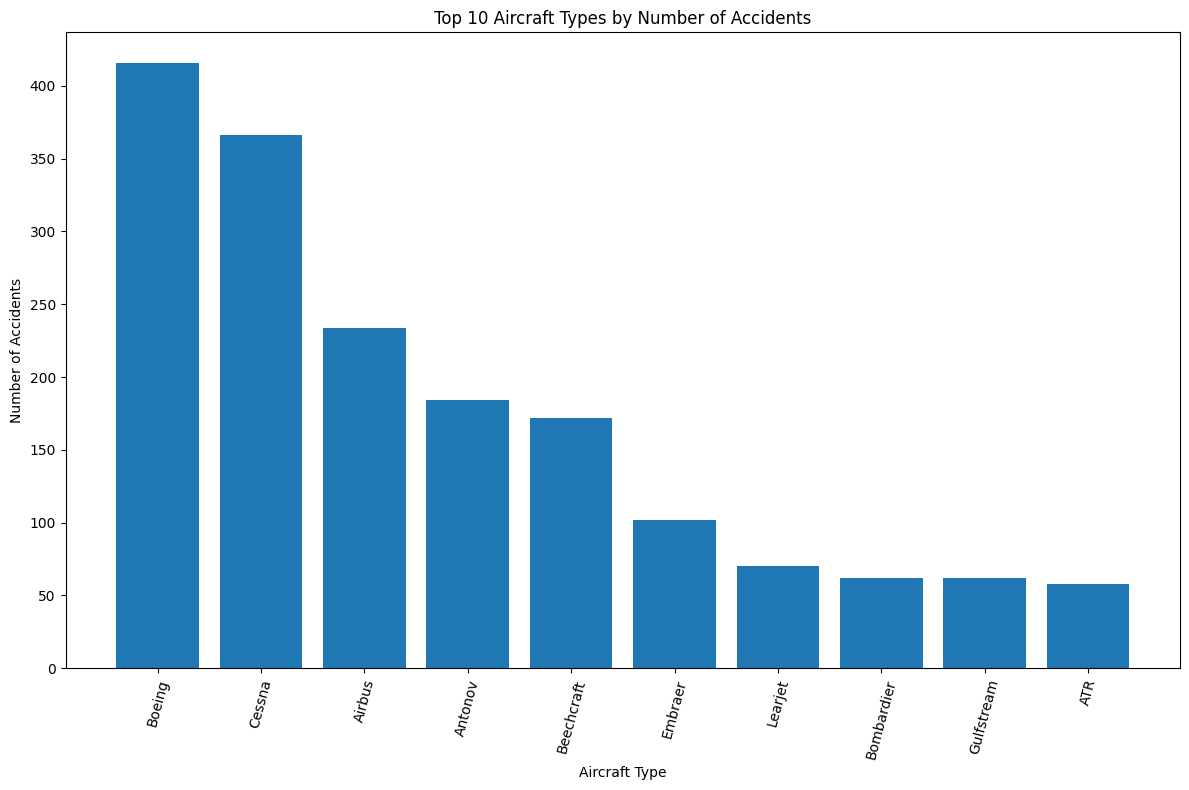

In [254]:
# Count accidents by aircraft type
type_accidents = flight_df['type'].value_counts()

# Select top 10 aircraft types with most accidents
top_10_types = type_accidents.head(10)

plt.figure()
plt.bar(top_10_types.index, top_10_types.values)
plt.xlabel('Aircraft Type')
plt.ylabel('Number of Accidents')
plt.title('Top 10 Aircraft Types by Number of Accidents')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


The charts show that aircraft types with larger and more widely used fleets, such as Boeing and Cessna, appear more frequently in accident records. This likely reflects higher exposure and operational volume rather than inherently lower safety. That is why it would be best to analyze fatalities by aircraft type.

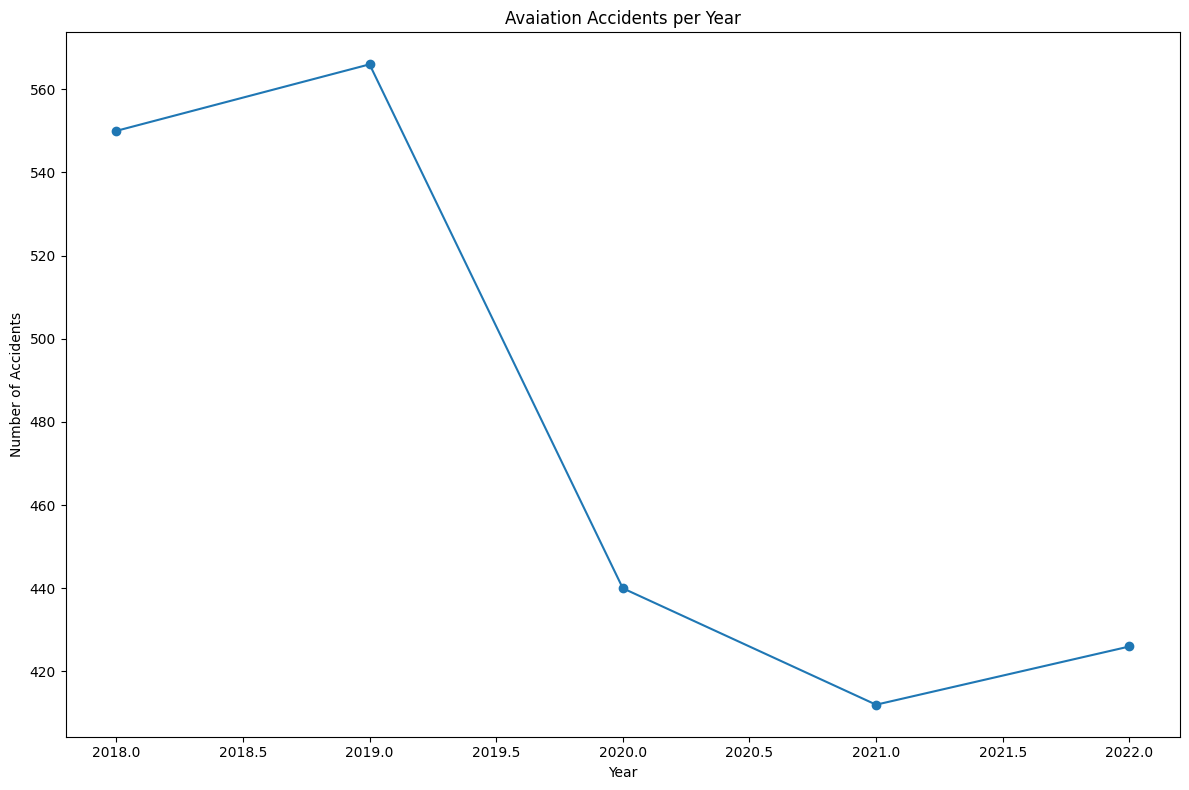

In [255]:
# Convert acc.date to datetime format
flight_df['acc.date'] = pd.to_datetime(
    flight_df['acc.date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'  # Handle invalid dates by setting them to NaT
)
# Extract year from acc.date
flight_df['acc.year'] = flight_df['acc.date'].dt.year

# Count accidents per year
accidents_per_year = flight_df.groupby('acc.year').size()

# Plot line chart of accidents per year
plt.figure()
plt.plot(accidents_per_year.index, accidents_per_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.title('Avaiation Accidents per Year')   
plt.tight_layout()
plt.show()

Time series trend shows that:

1. 2018 -2019 (Slight increase):

This maybe be likey due to increase in air traffic and more flights that equals more exposure. 

2. 2019 - 2020 (Sharp Drop):

Due to the COVID-19 pandemic, flights were grounded due to quarantine meaning fewer flights, fewer takeoffs and landings. Accidents drop due to reduced operations. 

3. 2020 - 2021 (Continued decline):

Aviation still recovering with limited routes and fewer fights.

4. 2021 - 2022:

Air travel resumes, fleets returning to service and exposure increases again. Reflects the gradual recovery of aviation activity rather than a deterioration in safety. 

### 5.2 Diagnostic Analysis

This helps us answer the question 'Why did it happen?'. We investigate relationship in the data ato explain patterns seen in descriptive analysis. 
Key areas of focus include comparing aircraft types with the number of fatalities to determine whether certain aircraft are associated with more severe outcomes, as well as analyzing the relationship between damage severity and fatalities.

By examining these relationships, the analysis moves beyond simple accident counts and provides insight into factors that may influence accident severity.

In [256]:
# Confirm data type of 'fat' column
flight_df['fat'].dtype

dtype('O')

In [257]:
flight_df['fat'] = pd.to_numeric(flight_df['fat'], errors='coerce')
flight_df['fat'].isna().sum()

np.int64(38)

<Figure size 1200x800 with 0 Axes>

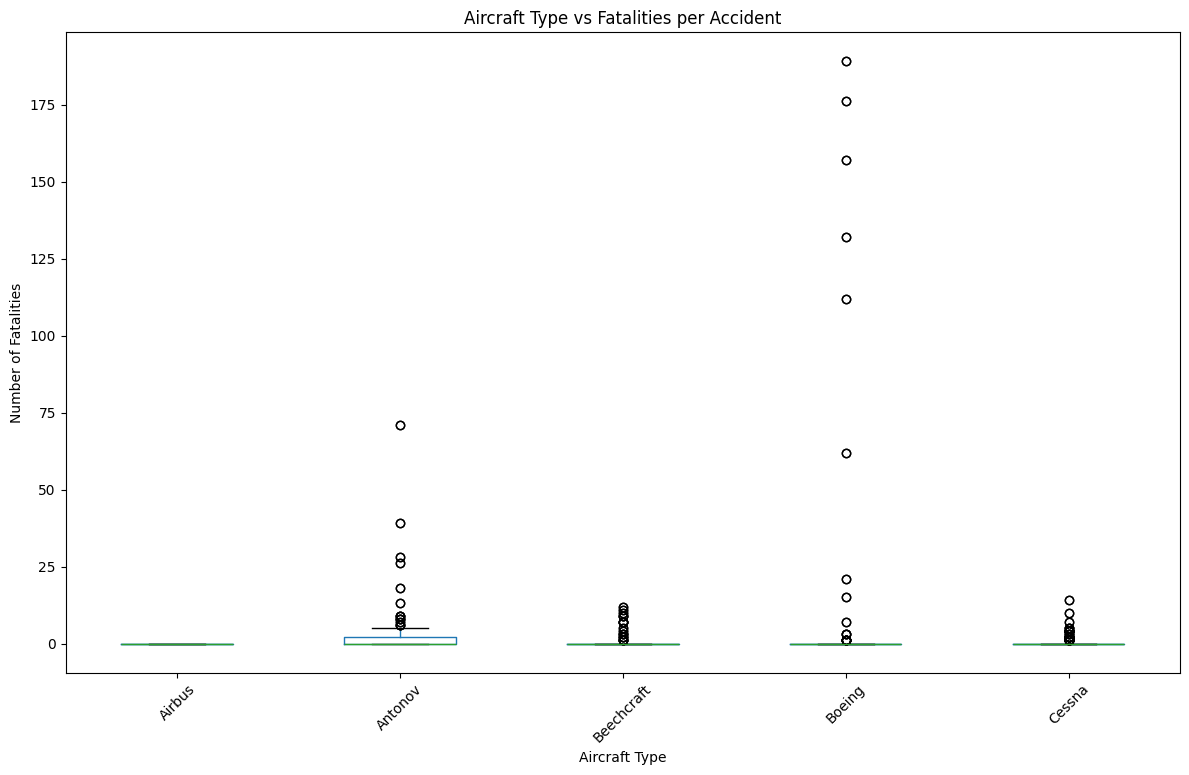

In [258]:
# Get top 5 aircraft tpes by number of accidents
top_5_types = flight_df['type'].value_counts().head(5).index

# Filter DataFrame for top 5 aircraft types
top_df = flight_df[flight_df['type'].isin(top_5_types)]

# Plot accidents per year for top 5 aircraft types
plt.figure()
top_df.boxplot(
    column ='fat',
    by='type',
    grid=False
)

plt.xlabel("Aircraft Type")
plt.ylabel("Number of Fatalities")
plt.title("Aircraft Type vs Fatalities per Accident")
plt.suptitle("")  # Removes automatic pandas title
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The box plot illustrates the distribution of fatalities per accident across major aircraft types. While the median number of fatalities is zero for all aircraft types, indicating that most accidents are non-fatal, some aircraft types such as Boeing and Antonov exhibit greater variability and more extreme outliers. This suggests that when accidents involving larger or specialized aircraft occur, they may result in higher fatality counts due to passenger capacity or operational conditions.

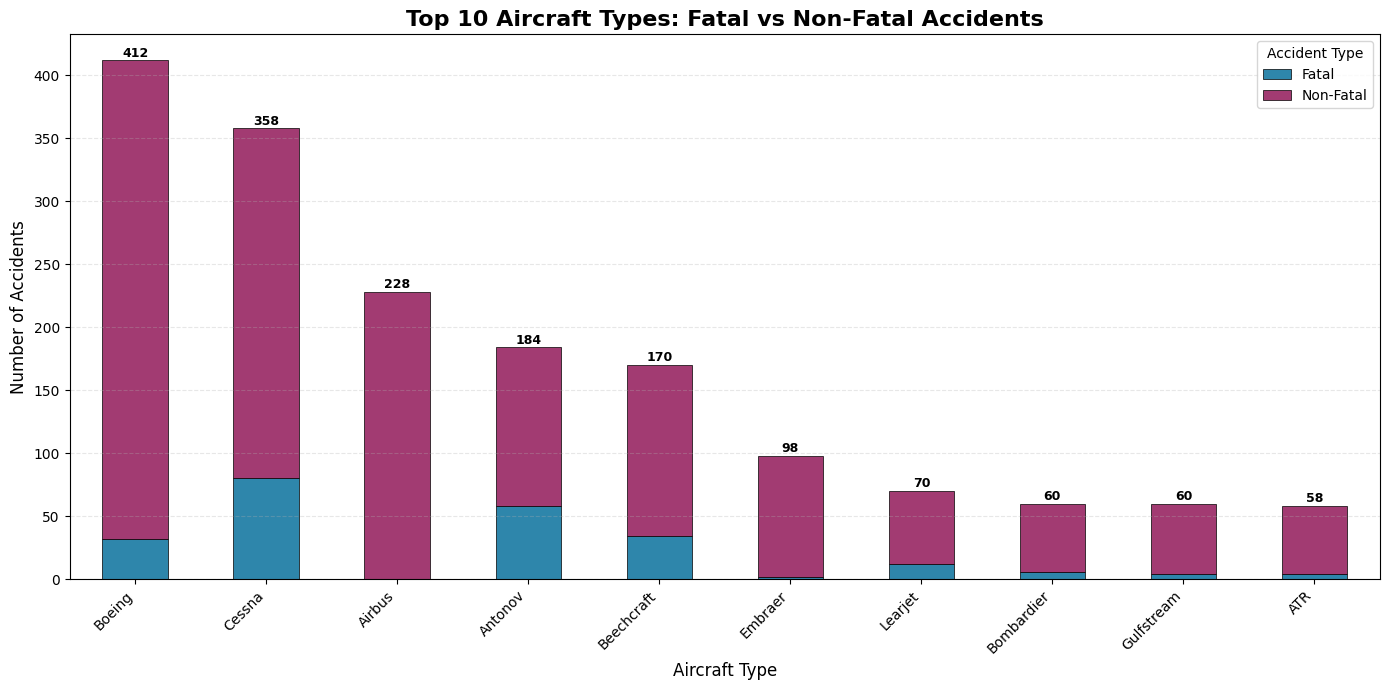

In [271]:
# Clean column names
flight_df.columns = flight_df.columns.str.strip()

# Convert fatalities to numeric
flight_df['fat'] = pd.to_numeric(flight_df['fat'], errors='coerce')

# Drop invalid rows
flight_df = flight_df.dropna(subset=['fat', 'type'])

# Create a new column for Fatal / Non-Fatal
flight_df['acc_type'] = flight_df['fat'].apply(lambda x: 'Fatal' if x > 0 else 'Non-Fatal')

# Count accidents per type
stacked_data = flight_df.groupby(['type', 'acc_type']).size().unstack(fill_value=0)

# Get top 10 aircraft types by total accidents
stacked_data['Total'] = stacked_data.sum(axis=1)
top_10 = stacked_data.nlargest(10, 'Total').drop('Total', axis=1)

# Plot stacked bar chart
ax = top_10.plot(kind='bar', stacked=True, figsize=(14, 7), 
                  color=['#2E86AB', '#A23B72'], edgecolor='black', linewidth=0.5)
plt.title('Top 10 Aircraft Types: Fatal vs Non-Fatal Accidents', fontsize=16, fontweight='bold')
plt.xlabel('Aircraft Type', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Accident Type', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add total count labels on top of bars
for i, (idx, row) in enumerate(top_10.iterrows()):
    total = row.sum()
    ax.text(i, total + 0.5, f'{int(total)}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

The data reveals significant pattern in aviation safety across different aircraft categories. Boeing leads with total accidents, but remarkably a small precentage in fatalities, reflecting the robust safety systemsin modern commercial jets and the manufacturer's extensive operational fleet. 

This pattern extends across the dataset: commercial manufacturers like Boeing, Airbus, and Embraer demonstrate lower fatality rates due to advanced safety features, rigorous training requirements, and multiple backup systems, while general aviation manufacturers such as Cessna and Beechcraft show higher fatality proportions despite fewer overall accidents. 

The data underscores that total accident counts don't necessarily correlate with danger, context matters significantly. Boeing's high accident count reflects decades of operations across thousands of aircraft, while the survivability rate demonstrates substantial progress in aviation safety engineering. Overall, the findings highlight how aircraft size, purpose, and safety systems dramatically influence accident outcomes in modern aviation.

In [ ]:
# Save the cleaned DataFrame to a new CSV file
flight_df.to_csv('cleaned_flight_data.csv', index=False)
test_df = pd.read_csv('cleaned_flight_data.csv')


### 6. Conclusion

**Prioritize Boeing and Airbus aircraft for fleet acquisition.**

These manufacturers offer an ideal balance between operational safety and financial risk management. While their aircraft come with **higher upfront costs**, their long-term valu, driven by outstanding **survivability, robust safety systems, and proven reliability**, ensures superior return on investment while shielding stakeholders from catastrophic financial losses and reputational harm.